In [4]:
#Error at different temperatures
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


n = np.linspace(0.05, 2.0, 1000)
l = 1/np.pi
r = 1.0

def volume(h, r, l):
    return (np.arccos((r-h)/r)*r**2 - (r-h)*np.sqrt(2*h*r - h**2)) * l

a = np.zeros(1000)
for i in range(1000):
    a[i] = volume(n[i], r, l)

depth_from_volume = interp1d(a, n)


target_volumes_litres = np.arange(50, 1001, 50)
target_volumes = target_volumes_litres / 1000
dipstick_depths = depth_from_volume(target_volumes)


beta = 0.00099
reference_temp = 8


# temperatures = [-10,-5,0,5, 10, 14, 20, 25]
temperatures=[7,10,14]

def volume_at_temperature(volume_at_15C, temperature):
    temp_difference = temperature - reference_temp
    volume_correction = 1 + beta * temp_difference
    apparent_volume = volume_at_15C * volume_correction
    return apparent_volume



print(f"{'Temperature':>12} | {'Apparent Volume':>16} | {'Error':>10}")
print("-"*45)


true_volume_500L = 500

for temp in temperatures:
    apparent_vol = volume_at_temperature(true_volume_500L, temp)
    error = apparent_vol - true_volume_500L
    print(f"{temp:>12}°C | {apparent_vol:>16.2f}L | {error:>+9.2f}L")




test_temps = [10, 14, 20]

for temp in test_temps:
    print(f"\n--- At {temp}°C ---")
    print(f"{'True Volume':>12} | {'Depth':>10} | {'Apparent Volume':>16} | {'Error':>10}")
    print("-"*55)

    for true_vol, depth in zip(target_volumes_litres[:10], dipstick_depths[:10]):
        apparent_vol = volume_at_temperature(true_vol, temp)
        error = apparent_vol - true_vol
        print(f"{true_vol:>12}L | {depth*100:>9.2f}cm | {apparent_vol:>16.2f}L | {error:>+9.2f}L")

 Temperature |  Apparent Volume |      Error
---------------------------------------------
           7°C |           499.50L |     -0.50L
          10°C |           500.99L |     +0.99L
          14°C |           502.97L |     +2.97L

--- At 10°C ---
 True Volume |      Depth |  Apparent Volume |      Error
-------------------------------------------------------
          50L |     19.46cm |            50.10L |     +0.10L
         100L |     31.30cm |           100.20L |     +0.20L
         150L |     41.49cm |           150.30L |     +0.30L
         200L |     50.81cm |           200.40L |     +0.40L
         250L |     59.60cm |           250.50L |     +0.50L
         300L |     68.03cm |           300.59L |     +0.59L
         350L |     76.21cm |           350.69L |     +0.69L
         400L |     84.23cm |           400.79L |     +0.79L
         450L |     92.14cm |           450.89L |     +0.89L
         500L |    100.00cm |           500.99L |     +0.99L

--- At 14°C ---
 True V

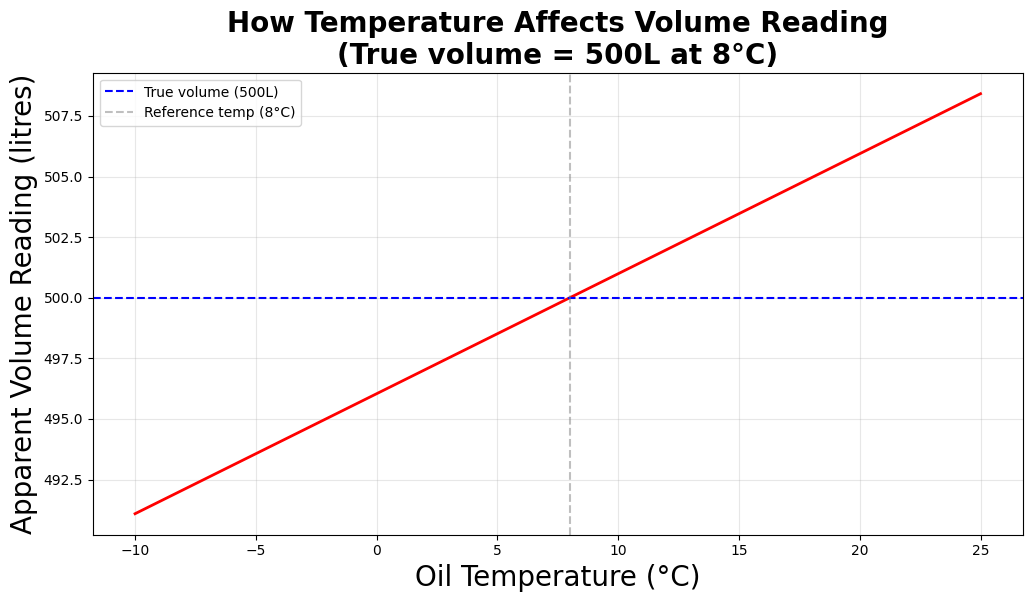

In [3]:
plt.figure(figsize=(12, 6))

#worst case for reading error
test_volume = 500
test_depth = dipstick_depths[np.where(target_volumes_litres == test_volume)[0][0]]

temp_range = np.linspace(-10, 25, 100)
apparent_volumes = [volume_at_temperature(test_volume, t) for t in temp_range]
errors = [av - test_volume for av in apparent_volumes]


plt.plot(temp_range, apparent_volumes, 'r-', linewidth=2)
plt.axhline(y=test_volume, color='blue', linestyle='--', label=f'True volume ({test_volume}L)')
plt.axvline(x=reference_temp, color='gray', linestyle='--', alpha=0.5, label=f'Reference temp ({reference_temp}°C)')
plt.xlabel('Oil Temperature (°C)', fontsize=20)
plt.ylabel('Apparent Volume Reading (litres)', fontsize=20)
plt.title(f'How Temperature Affects Volume Reading\n(True volume = {test_volume}L at {reference_temp}°C)', fontsize=20, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig("How Temperature Affects Volume Reading.pdf", format="pdf", bbox_inches="tight")

plt.legend()






/tmp/ipython-input-3909791243.py:11: RuntimeWarning: invalid value encountered in arccos
  return (np.arccos((r-h)/r)*r**2 - (r-h)*np.sqrt(2*h*r - h**2)) * l
/tmp/ipython-input-3909791243.py:11: RuntimeWarning: invalid value encountered in sqrt
  return (np.arccos((r-h)/r)*r**2 - (r-h)*np.sqrt(2*h*r - h**2)) * l


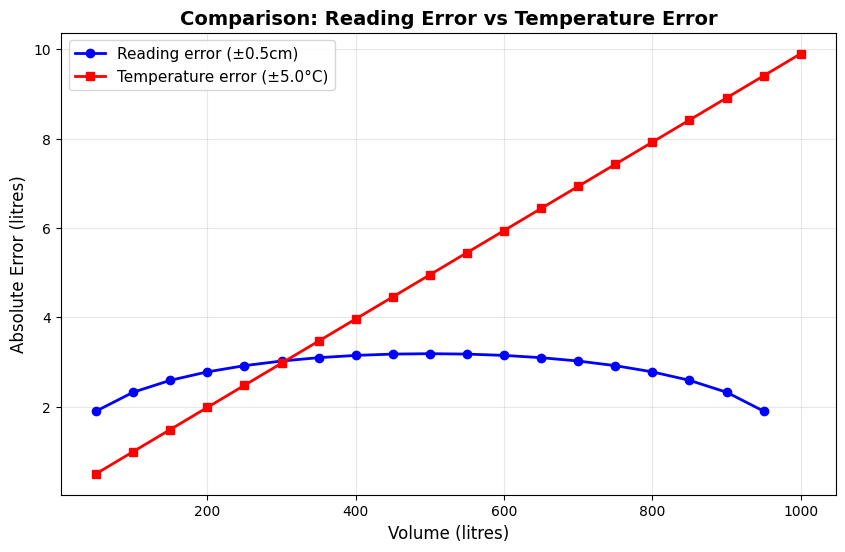

In [ ]:

plt.figure(figsize=(10, 6))

reading_error_cm = 0.5
reading_error_m = reading_error_cm / 100

reading_errors = []
for vol, depth in zip(target_volumes_litres, dipstick_depths):
    V_plus = volume(depth + reading_error_m, r, l) * 1000
    V_minus = volume(depth - reading_error_m, r, l) * 1000
    error_litres = max(abs(V_plus - vol), abs(V_minus - vol))
    reading_errors.append(error_litres)

temp_variation = 10
temp_errors = [vol * beta * temp_variation for vol in target_volumes_litres]

# Plot both
plt.plot(target_volumes_litres, reading_errors, 'b-o', linewidth=2,
         markersize=6, label='Reading error (±0.5cm)')
plt.plot(target_volumes_litres, temp_errors, 'r-s', linewidth=2,
         markersize=6, label=f'Temperature error (±{temp_variation/2}°C)')

plt.xlabel('Volume (litres)', fontsize=12)
plt.ylabel('Absolute Error (litres)', fontsize=12)
plt.title('Comparison: Reading Error vs Temperature Error', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig("error_comparison.pdf", format="pdf")
plt.show()


